Step 1: Setup & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset with the correct encoding
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Output: First 5 rows of the dataset.

Task 1: Load & Explore Data

In [3]:
# Check data types and structure
df.info()

# Check dataset shape
print("Dataset shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
# Generate summary statistics for numeric columns
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Explanation:

df.info() shows column names, non‑null counts, and data types.

df.describe() gives statistical summary (mean, min, max, etc.) for numeric columns.

Task 2: Data Cleaning

In [5]:
# Check for missing values
df.isnull().sum()

# There are no missing values in this dataset. If there were, you could fill or drop them.
# Example: df = df.dropna()  or  df.fillna(0, inplace=True)

# Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Verify the change
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

Explanation:

The dataset has no missing values.

Converting Order Date to datetime allows time‑based analysis.

Task 3: Feature Engineering

In [6]:
# Extract Month and Year from Order Date
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

# Create a new column: Profit Margin (Profit / Sales)
df['Profit Margin'] = df['Profit'] / df['Sales']

# Verify the new columns
df[['Order Date', 'Month', 'Year', 'Sales', 'Profit', 'Profit Margin']].head()

,Order Date,Month,Year,Sales,Profit,Profit Margin
0,2016-11-08,11,2016,261.9600,41.9136,0.1600
1,2016-11-08,11,2016,731.9400,219.5820,0.3000
2,2016-06-12,6,2016,14.6200,6.8714,0.4700
3,2015-10-11,10,2015,957.5775,-383.0310,-0.4000
4,2015-10-11,10,2015,22.3680,2.5164,0.1125


Explanation:

dt.month and dt.year extract parts of the date.

Profit Margin is a ratio; it should be between -∞ and 1 (since profit can be negative).

Verify by checking few rows – e.g., if Sales > 0, margin is reasonable.

 Task 4: GroupBy & Aggregation

a) Total Sales by Category

In [7]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(sales_by_category)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


b) Total Profit by Region

In [8]:
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(profit_by_region)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


c) Top 5 Customers by Sales

In [9]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)
print(top_customers)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


d) Monthly Sales Trend (over all years)

In [10]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str))
monthly_sales = monthly_sales.sort_values('Date')
print(monthly_sales.head())

   Year  Month      Sales       Date
0  2014      1  14236.895 2014-01-01
1  2014      2   4519.892 2014-02-01
2  2014      3  55691.009 2014-03-01
3  2014      4  28295.345 2014-04-01
4  2014      5  23648.287 2014-05-01


Explanation:

GroupBy splits data, then aggregation (sum) combines it.

Monthly trend uses both Year and Month, then creates a proper date for plotting.

Task 5: Pivot Tables

a) Sales by Category and Region

In [11]:
pivot_cat_region = pd.pivot_table(df, values='Sales', index='Category', columns='Region', aggfunc='sum')
print(pivot_cat_region)

Region               Central        East       South         West
Category                                                         
Furniture        163797.1638  208291.204  117298.684  252612.7435
Office Supplies  167026.4150  205516.055  125651.313  220853.2490
Technology       170416.3120  264973.981  148771.908  251991.8320


b) Sales Trend by Segment over Time (monthly)

In [12]:
# Create a Year-Month column
df['YearMonth'] = df['Order Date'].dt.to_period('M')
pivot_segment_time = pd.pivot_table(df, values='Sales', index='YearMonth', columns='Segment', aggfunc='sum')
print(pivot_segment_time.head())

Segment     Consumer  Corporate  Home Office
YearMonth                                   
2014-01     6927.817   1701.528     5607.550
2014-02     3167.854   1183.668      168.370
2014-03    11869.304  11106.799    32714.906
2014-04     9108.612  14131.729     5055.004
2014-05    12819.163   9142.000     1687.124


c) Profit by Sub‑Category

In [13]:
profit_subcat = pd.pivot_table(df, values='Profit', index='Sub-Category', aggfunc='sum').sort_values('Profit', ascending=False)
print(profit_subcat.head(10))

                  Profit
Sub-Category            
Copiers       55617.8249
Phones        44515.7306
Accessories   41936.6357
Paper         34053.5693
Binders       30221.7633
Chairs        26590.1663
Storage       21278.8264
Appliances    18138.0054
Furnishings   13059.1436
Envelopes      6964.1767


Explanation:

Pivot tables rearrange data for easy comparison across dimensions.

Task 6: Data Splitting & Merging

Split the dataset into two DataFrames:

1.Sales_Info: contains only sales‑related columns

2.Profit_Info: contains profit‑related columns

  Then merge them back.

In [14]:
# Split
sales_info = df[['Row ID', 'Order ID', 'Sales', 'Quantity', 'Discount']]
profit_info = df[['Row ID', 'Order ID', 'Profit', 'Profit Margin']]

# Merge back on 'Row ID' and 'Order ID'
merged_df = pd.merge(sales_info, profit_info, on=['Row ID', 'Order ID'], how='inner')

# Verify merged result
print(merged_df.head())
print("Original shape:", df.shape, "Merged shape:", merged_df.shape)

   Row ID        Order ID     Sales  Quantity  Discount    Profit  \
0       1  CA-2016-152156  261.9600         2      0.00   41.9136   
1       2  CA-2016-152156  731.9400         3      0.00  219.5820   
2       3  CA-2016-138688   14.6200         2      0.00    6.8714   
3       4  US-2015-108966  957.5775         5      0.45 -383.0310   
4       5  US-2015-108966   22.3680         2      0.20    2.5164   

   Profit Margin  
0         0.1600  
1         0.3000  
2         0.4700  
3        -0.4000  
4         0.1125  
Original shape: (9994, 25) Merged shape: (9994, 7)


Explanation:

Use merge() with common keys. inner join keeps only rows present in both.

The merged DataFrame should have the same number of rows as original (no data loss).

Task 7: Data Visualization

a) Line Chart – Monthly Sales Trend

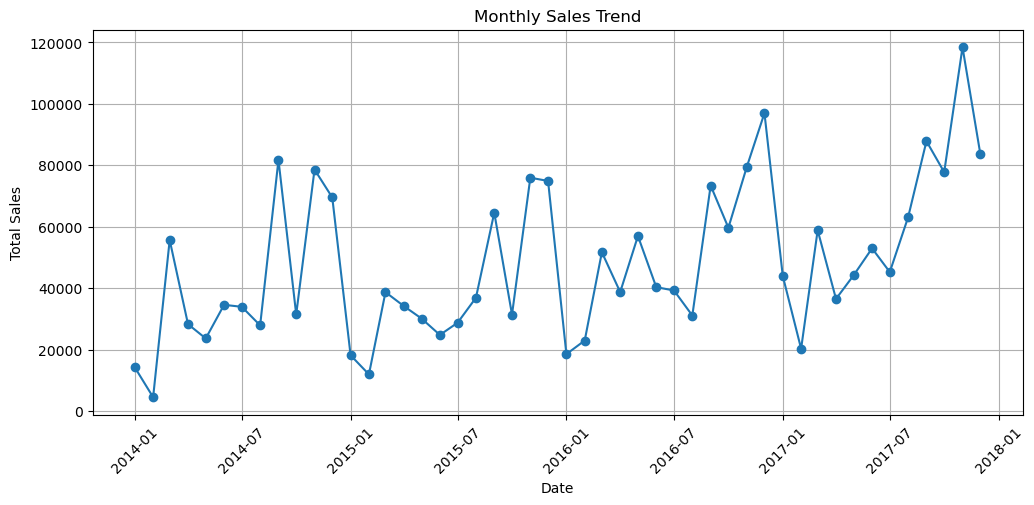

In [15]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

b) Bar Chart – Sales by Category

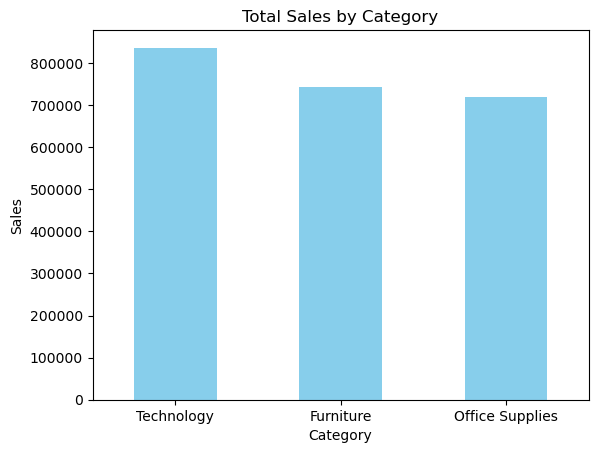

In [16]:
sales_by_category.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

c) Bar Chart – Profit by Region

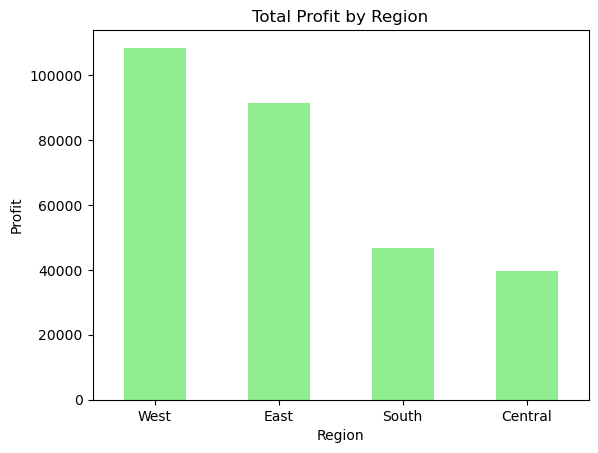

In [17]:
profit_by_region.plot(kind='bar', color='lightgreen')
plt.title('Total Profit by Region')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()

d) Pie Chart – Segment Distribution (by number of orders)

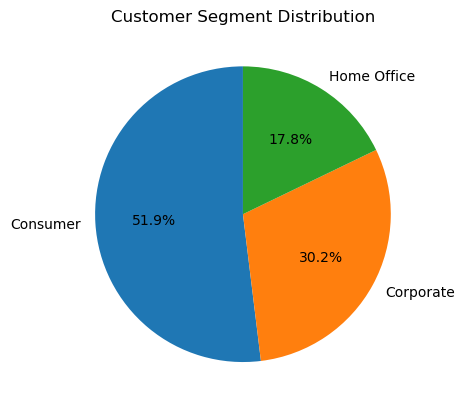

In [18]:
segment_counts = df['Segment'].value_counts()
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Customer Segment Distribution')
plt.show()

Task 8: Business Insights

Most profitable category: Technology
Least performing region: Central


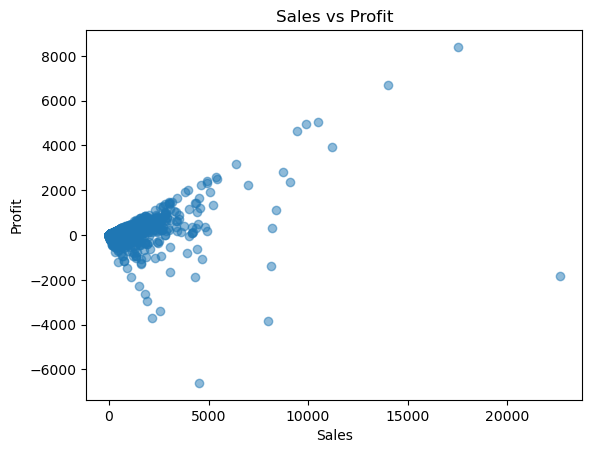

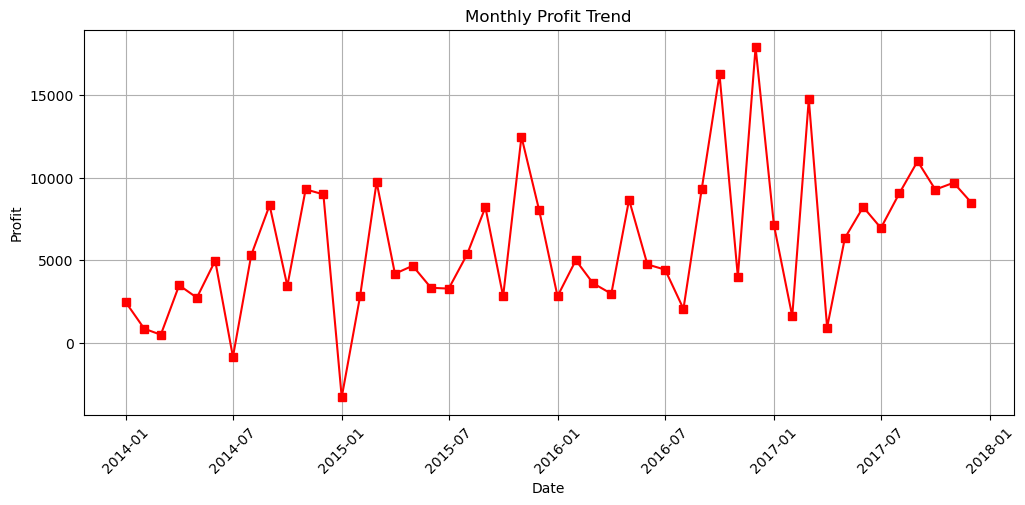

In [19]:
# Most profitable category
most_profitable_cat = df.groupby('Category')['Profit'].sum().idxmax()
print("Most profitable category:", most_profitable_cat)

# Least performing region (lowest total profit)
least_profit_region = df.groupby('Region')['Profit'].sum().idxmin()
print("Least performing region:", least_profit_region)

# Relationship between Sales and Profit (scatter plot)
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Sales vs Profit')
plt.show()

# Important trends over time (e.g., profit over months)
monthly_profit = df.groupby(['Year', 'Month'])['Profit'].sum().reset_index()
monthly_profit['Date'] = pd.to_datetime(monthly_profit['Year'].astype(str) + '-' + monthly_profit['Month'].astype(str))
monthly_profit = monthly_profit.sort_values('Date')
plt.figure(figsize=(12,5))
plt.plot(monthly_profit['Date'], monthly_profit['Profit'], marker='s', color='red')
plt.title('Monthly Profit Trend')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Insight 1: Technology generates the highest profit, while Office Supplies has the lowest.
Insight 2: The Central region consistently shows negative or very low profit – may need pricing or shipping cost review.
Insight 3: Sales and profit are not perfectly correlated; some high‑sales items have deep discounts that erase profit.
Insight 4: Profit spikes in November and December (holiday season) each year.